In [1]:
from spiderstate.cat_at_origin import *
from spidercat.draw import draw_forest_on_graph
from spiderstate.utils import load_qecc

%load_ext autoreload
%autoreload 2

In [9]:
is_self_dual, H_x, H_z, L_x, L_z, d = load_qecc("12_2_4", "MQT")
t = d // 2

row_M, final_M, col_ops = optimize_fault_tolerant_matrix(H_z, t=t, max_col_ops=0, max_basis_tries=10_000)
print(row_M, sep="\n\n")

[[0 0 0 0 0 0 0 0 1 1 1 1]
 [0 1 1 0 1 0 1 0 1 1 0 0]
 [1 1 1 1 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 1 1 0 1 0 1 0]
 [1 0 1 0 0 0 1 1 0 1 1 0]]


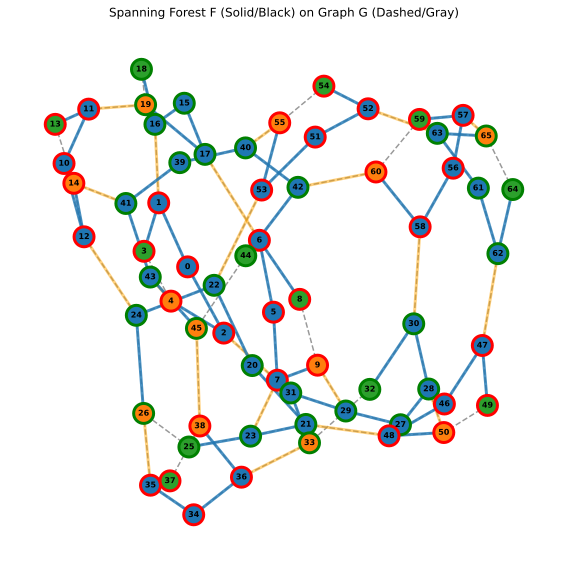

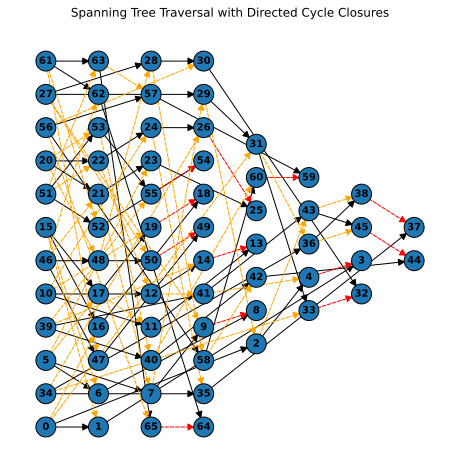

In [10]:
circ = cat_at_origin(row_M, d, draw_solutions=True)

R 0 1 2
RX 3 4 5
R 6
RX 7
R 8 9 10
RX 11 12
CX 12 0
RX 13
CX 13 1
RX 14
CX 14 2
R 15
CX 3 15
R 16
CX 4 16
R 17
CX 5 17
RX 18
CX 18 6
R 19
CX 7 19
RX 20
CX 20 8
RX 21
CX 21 9
RX 22
CX 22 10
R 23
CX 11 23 3 0 15 1 4 20 16 21 11 8 23 9 15 2 5 20 4 13 7 21 16 14 23 10 3 15
M 15
CX 20 8
MX 20
CX 5 22 17 13 21 9
MX 21
CX 16 6 19 14 11 23
M 23
CX 7 22 13 1
MX 13
CX 17 12 4 16
M 16
CX 14 2
MX 14
CX 22 10
MX 22
CX 17 18 19 12 5 17
M 17
CX 12 0
MX 12
CX 19 18 7 19
M 19
CX 18 6
MX 18
DETECTOR rec[-12]
DETECTOR rec[-11]
DETECTOR rec[-10]
DETECTOR rec[-9]
DETECTOR rec[-8]
DETECTOR rec[-7]
DETECTOR rec[-6]
DETECTOR rec[-5]
DETECTOR rec[-4]
DETECTOR rec[-3]
DETECTOR rec[-2]
DETECTOR rec[-1]


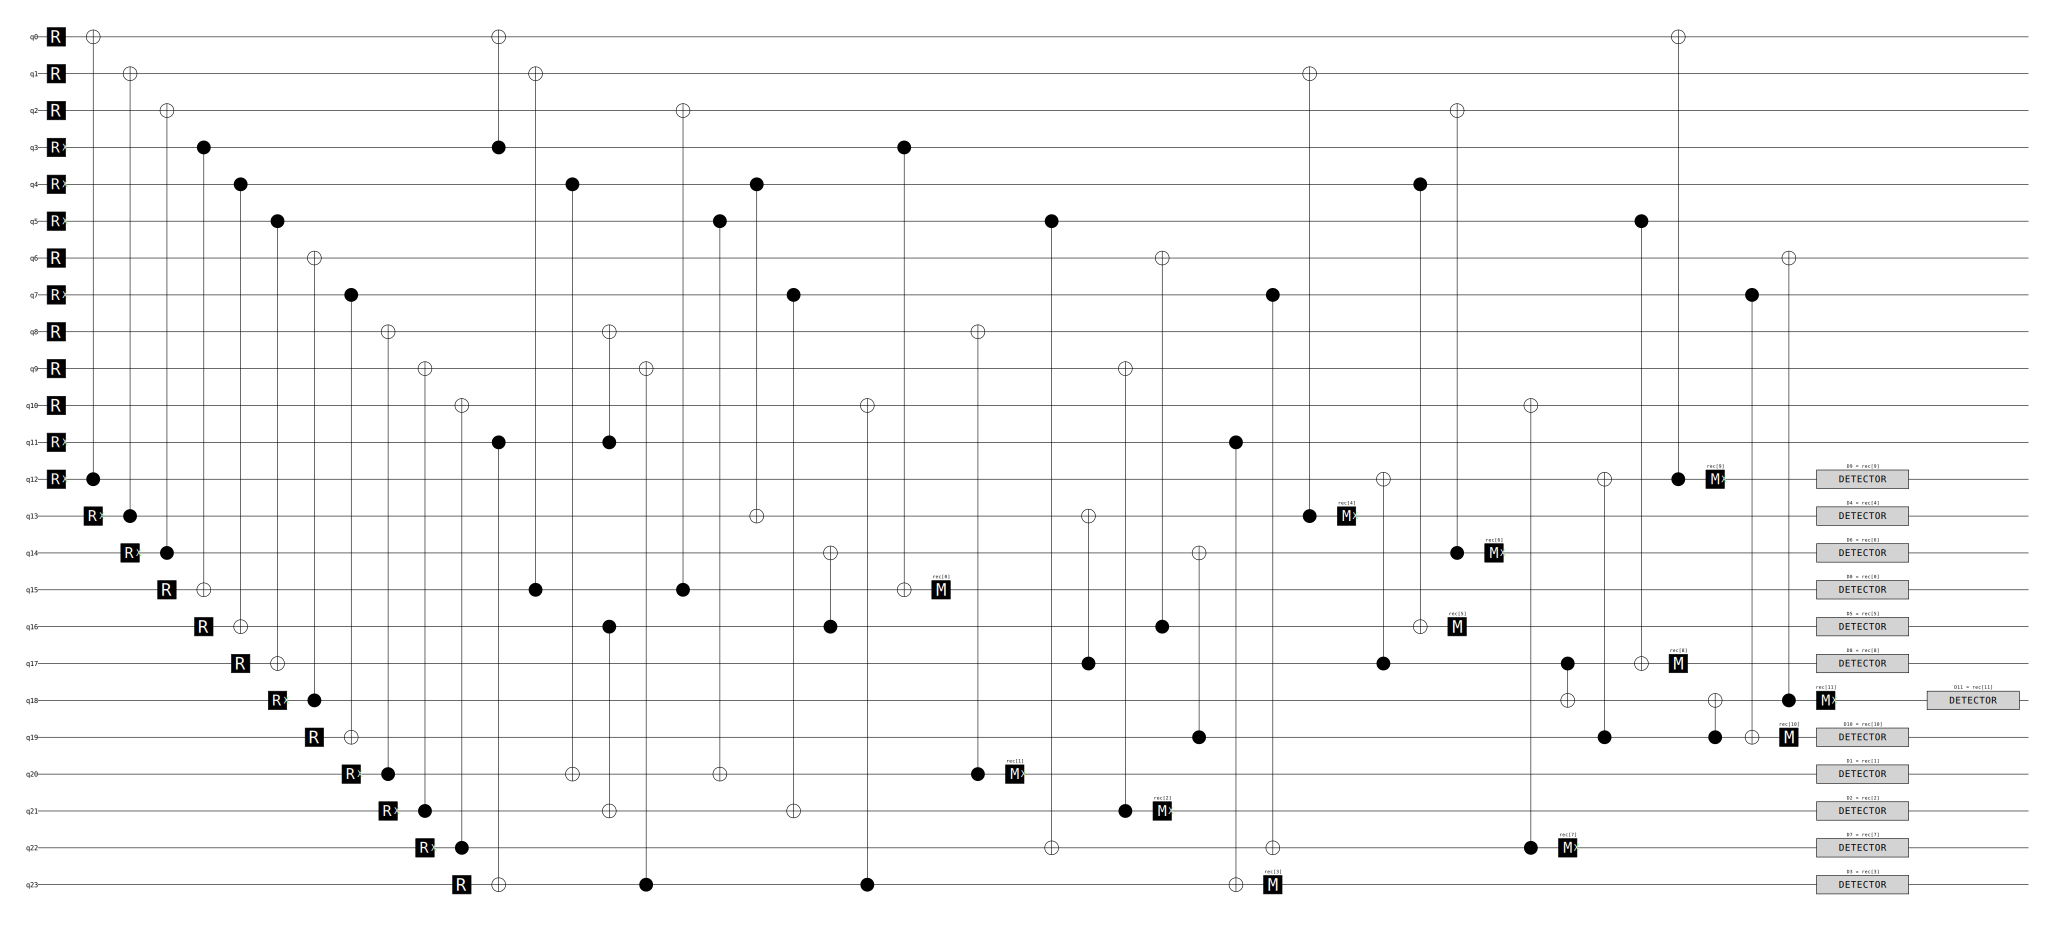

In [11]:

print(circ)
circ.diagram('timeline-svg')

In [12]:
circuit = circ.copy()
circuit.append("M", range(H_z.shape[1]))
samples = circuit.compile_sampler().sample(10)
meas_samples = samples[:, -H_z.shape[1]:]
print(meas_samples @ H_z.T % 2)
print(meas_samples @ L_x.T % 2)

[[0 0 0 0 1]
 [0 0 0 1 1]
 [0 0 0 0 1]
 [0 0 0 1 0]
 [0 0 0 1 0]
 [0 0 0 1 1]
 [0 0 0 1 1]
 [0 0 0 0 0]
 [0 0 0 1 1]
 [0 0 0 0 0]]
[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]]


In [13]:
from spidercat.simulate import _layer_cnot_circuit

raw_cnots = [l for (name, l, _) in circ.flattened_operations() if name == "CX"]
cnots = [(ops[i], ops[i + 1]) for ops in raw_cnots for i in range(0, len(ops), 2)]
print("Num CX:", len(cnots))
print("Num Flags:", circ.num_qubits - H_z.shape[1])
print("Num qubits:", circ.num_qubits)
layered_cnots = _layer_cnot_circuit(cnots)
print("Depth:", len(layered_cnots))

Num CX: 45
Num Flags: 12
Num qubits: 24
Depth: 8


In [14]:
print(np.sum(row_M, axis=0))
print(np.sum(row_M, axis=1))

[3 3 3 1 1 1 3 1 3 3 3 1]
[4 6 4 6 6]


In [15]:
print(np.sum(H_z, axis=0))
print(np.sum(H_z, axis=1))

[3 1 2 2 2 1 3 2 2 1 2 3]
[4 4 4 6 6]


In [16]:
import pprint
for r in row_M:
    pprint.pprint(r, width=400)

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1])
array([0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0])
array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0])
array([1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0])
array([1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0])


In [12]:
with open("64_8_8.stim", "w") as f:
    f.write(str(circ))